In [2]:
print('all ok')

all ok


In [3]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [4]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")

In [5]:
if not GROQ_API_KEY:
   raise ValueError("Groq api key is missing in your .env")
os.environ["GROQ_API_KEY"]=GROQ_API_KEY

In [6]:
from langchain_groq import ChatGroq

In [7]:
chat_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3
)


In [8]:
# Test the connection
try:
    response = chat_llm.invoke("Hello how are you?")
    print("✅ Success!")
    print(response.content)
except Exception as e:
    print(f"❌ Error: {e}")

✅ Success!
I'm functioning properly, thank you for asking. How can I assist you today?


In [9]:
chat_llm.invoke("Hello how are you ?").content

"I'm just a computer program, so I don't have feelings, but I'm functioning properly and ready to help you with any questions or tasks you may have. How can I assist you today?"

In [10]:
from typing_extensions import TypedDict, Annotated
import operator

In [11]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [12]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [13]:
{
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [14]:
["hi"]

['hi']

In [15]:
["hi","how are you?"]

['hi', 'how are you?']

In [16]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [17]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [18]:

from langgraph.graph import StateGraph

In [19]:

builder = StateGraph(GraphState)

In [20]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [21]:

builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [22]:

app = builder.compile()

In [23]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [24]:

from IPython.display import Image, display

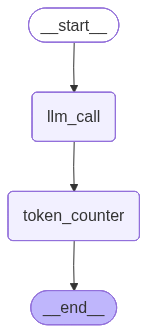

In [25]:
display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Rohit. what is Agentic AI? ")]
})

In [27]:

result

{'messages': [HumanMessage(content='Hi, this is Rohit. what is Agentic AI? ', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello Rohit, nice to meet you. Agentic AI refers to a type of artificial intelligence (AI) that exhibits autonomous decision-making and goal-oriented behavior, similar to that of an agent in a system. \n\nIn the context of AI, an agent is a software program or system that can perceive its environment, take actions, and adapt to new situations. Agentic AI systems are designed to operate independently, making decisions and taking actions to achieve specific goals, often without direct human intervention.\n\nSome key characteristics of agentic AI include:\n\n1. **Autonomy**: Agentic AI systems can operate independently, making decisions and taking actions without direct human input.\n2. **Goal-oriented behavior**: Agentic AI systems are designed to achieve specific goals, which can be set by humans or determined by the system itself.\n3. **Self-aw

In [28]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Rohit. what is Agentic AI? 
AIMessage : Hello Rohit, nice to meet you. Agentic AI refers to a type of artificial intelligence (AI) that exhibits autonomous decision-making and goal-oriented behavior, similar to that of an agent in a system. 

In the context of AI, an agent is a software program or system that can perceive its environment, take actions, and adapt to new situations. Agentic AI systems are designed to operate independently, making decisions and taking actions to achieve specific goals, often without direct human intervention.

Some key characteristics of agentic AI include:

1. **Autonomy**: Agentic AI systems can operate independently, making decisions and taking actions without direct human input.
2. **Goal-oriented behavior**: Agentic AI systems are designed to achieve specific goals, which can be set by humans or determined by the system itself.
3. **Self-awareness**: Agentic AI systems can have a sense of self, including an understanding of

In [29]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002951325FFB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029513291FD0>, model_name='llama-3.1-8b-instant', temperature=0.3, model_kwargs={}, groq_api_key=SecretStr('**********'))

# Tool Calling

In [30]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [31]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [32]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [33]:
wiki_tool.run({"query":"doraemon"})

"Page: Doraemon\nSummary: Doraemon (ドラえもん) is a Japanese manga series written and illustrated by Fujiko F. Fujio. First serialized in 1969, the manga's chapters were collected in 45 tankōbon volumes published by Shogakukan from 1974 to 1996. The story revolves around an earless robotic cat named Doraemon, who travels back in time from the 22nd century to assist a boy named Nobita Nobi in his day-to-day life.\nThe manga spawned a media franchise. It was adapted into three different anime TV series i"

In [34]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
#print(f"API Key: {TAVILY_API_KEY}")

In [35]:
#tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [36]:
#tool.invoke({"query":"what is the latest news about gen AI ?"})

In [37]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [38]:
search.invoke("what is latest update about the AI Submit ?")

Impersonate 'safari_16' does not exist, using 'random'


"5 days ago · OpenAI said it will open two new offices in India in Bengaluru and Mumbai. OpenAI also partnered with the Tata group to deploy 100 megawatts of compute in India ... 4 days ago · AI for all: On the India AI Impact Summit 2026. The AI Impact Summit was a sign of things to come in India. Updated - February 24, 2026 01:29 am IST. 0. READ ... 2 hours ago · Follow us on Google News for Breaking and Latest News Updates: NDTV: https ... AI Summit | What AI Builders Need To Win: India's Leap Into The Future. 8 ... 6 days ago · India hosted one of the world's biggest AI events this week, but it was marred by impossible traffic and a lack of organization. 59 minutes ago · The world of artificial intelligence was about to shift on its axis. From February 16 to 20, New Delhi's Bharat Mandapam hosted the India AI Impact Summit 2026."

In [39]:
from langchain_community.tools import YouTubeSearchTool
y_tool=YouTubeSearchTool()

In [40]:
y_tool.name

'youtube_search'

In [41]:
y_tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [42]:
y_tool.run("Krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKS3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=fQw1_U22URk&pp=ygUKS3Jpc2ggbmFpaw%3D%3D']"

# Custom tool

In [43]:
from langchain.tools import tool

In [44]:
@tool
def multiple(a:int,b:int)-> int:
    '''This is custom tool for multiple'''
    return a*b

In [45]:
multiple.invoke({'a':2,'b':4})

8

In [46]:
@tool
def get_len(word:str)->int:
    '''THis tool give length of words'''
    return len(word)

In [47]:
get_len.invoke({'word':"rohit yadav"})

11

In [48]:
get_len.invoke("tommorow")

8

In [49]:
import yfinance as yf

In [50]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [51]:
get_stock_price.invoke('AAPL')

'The last closing price of AAPL was $272.95.'

In [52]:
get_stock_price.invoke('TSLA')

'The last closing price of TSLA was $408.58.'

In [53]:
tools=[get_stock_price,get_len,multiple,wiki_tool]

In [54]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002951325FFB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029513291FD0>, model_name='llama-3.1-8b-instant', temperature=0.3, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [55]:
llm_with_tools=chat_llm.bind_tools(tools)

In [56]:
result=llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [57]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'm89pt51ct', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 465, 'total_tokens': 483, 'completion_time': 0.028334155, 'completion_tokens_details': None, 'prompt_time': 0.028657332, 'prompt_tokens_details': None, 'queue_time': 0.046876078, 'total_time': 0.056991487}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c9e37-67f6-76f1-b358-762f541136b0-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'm89pt51ct', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 465, 'output_tokens': 18, 'total_tokens': 483})

In [59]:
result.content

''

In [60]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'm89pt51ct',
  'type': 'tool_call'}]

In [61]:
result=llm_with_tools.invoke("how many words are ther in HELLO WOrld?")

In [62]:
result.content

''

In [63]:
result.tool_calls

[{'name': 'get_len',
  'args': {'word': 'HELLO WOrld'},
  'id': 'z0m66bk31',
  'type': 'tool_call'}]

In [67]:
result=llm_with_tools.invoke("what was is todays latest news?")

In [68]:
result.content

'<brave_search>latest news today</brave_search>'

In [69]:
result.tool_calls

[]

In [70]:
result=llm_with_tools.invoke("hi how are you?")

In [71]:
result.content

"I'm functioning properly, thank you for asking. What can I assist you with today?"

In [72]:
result.tool_calls

[]